In [1]:
import pandas as pd
import numpy as np

In [2]:
%pwd
%cd /home/jovyan/work/COVID/results/
%pwd

/home/jovyan/work/COVID/results


'/home/jovyan/work/COVID/results'

In [3]:
# import the PCC data
pcc_ctrl = pd.read_csv("pcc_control.csv", index_col=0)
pcc_ctrl

,AL627309.1,AL627309.4,AL732372.1,AL669831.2,AL669831.5,FAM87B,LINC00115,FAM41C,AL645608.7,AL645608.3,...,AL592183.1,AC007325.1,AC007325.4,AC007325.2,AL354822.1,AC023491.2,AC004556.1,AC233755.2,AC233755.1,AC240274.1
AL627309.1,1.000000,0.355817,0.228245,0.445432,0.383732,0.251694,0.398397,-0.180755,0.211937,0.506467,...,-0.219447,0.089707,-0.075948,0.367428,0.444251,-0.049202,-0.164801,0.182791,0.104667,-0.109492
AL627309.4,0.355817,1.000000,-0.020470,0.560937,0.581096,0.312776,0.630832,-0.019241,0.363555,0.714848,...,-0.258779,0.110143,-0.136197,-0.158947,0.505242,-0.091704,-0.032674,0.054308,0.144107,0.010559
AL732372.1,0.228245,-0.020470,1.000000,0.074559,0.122271,0.018383,0.211597,0.053498,0.472034,0.054544,...,-0.174837,0.118689,0.040996,0.618964,0.250344,0.136197,0.064839,0.529239,0.321262,-0.244606
AL669831.2,0.445432,0.560937,0.074559,1.000000,0.342962,0.114597,0.372664,-0.112743,0.512556,0.649911,...,-0.050993,0.207640,0.117096,0.047820,0.563173,0.151045,-0.056025,0.008447,0.011003,0.040818
AL669831.5,0.383732,0.581096,0.122271,0.342962,1.000000,0.273196,0.748895,0.091072,0.314765,0.647219,...,-0.206828,0.171393,-0.163116,-0.092695,0.395888,0.014234,0.078203,0.192516,0.205644,0.267993
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AC023491.2,-0.049202,-0.091704,0.136197,0.151045,0.014234,-0.069917,0.019486,-0.033949,0.158318,0.049841,...,-0.021710,0.667373,0.029373,0.267866,0.015188,1.000000,0.053339,-0.085043,-0.091648,-0.038598
AC004556.1,-0.164801,-0.032674,0.064839,-0.056025,0.078203,-0.128880,-0.011038,0.372018,0.270079,-0.002586,...,-0.198202,-0.091038,-0.335324,-0.101195,-0.354331,0.053339,1.000000,-0.141557,-0.107665,0.348891
AC233755.2,0.182791,0.054308,0.529239,0.008447,0.192516,0.080272,0.211016,-0.149634,0.215407,0.047768,...,-0.226518,0.060870,0.063155,0.153132,0.390805,-0.085043,-0.141557,1.000000,0.672246,-0.300307
AC233755.1,0.104667,0.144107,0.321262,0.011003,0.205644,0.118125,0.207483,-0.106997,0.124246,0.076481,...,-0.163637,0.004468,0.016443,0.038674,0.253158,-0.091648,-0.107665,0.672246,1.000000,-0.207532


In [4]:
# Set the name of the DataFrame
pcc_ctrl.name = "pcc_ctrl"

construct a weighted graph of edges based on 1-abs(PCC-value)

delete rows and columns with Inf entries, since those genes are deleted from the module. (already ensured the genes won't contribute to potential modules candidates by assuring only 1 connected component is >= 3 in the previous graph)

In [5]:
import sys
sys.path.append('/home/jovyan/work/FUNCTIONS/')
from methods import Leiden_pcc_to_module, module_to_json

In [6]:
%pwd
%cd /home/jovyan/work/COVID/parameter_tuning/pcc_leiden/Cell/
%pwd

/home/jovyan/work/COVID/parameter_tuning/pcc_leiden/Cell


'/home/jovyan/work/COVID/parameter_tuning/pcc_leiden/Cell'

Cell: resolution = 0.35 
PCC_thres = 0.5

IGRAPH UNW- 26571 2589516 -- 
+ attr: name (v), weight (e)
Number of connected components: 4356


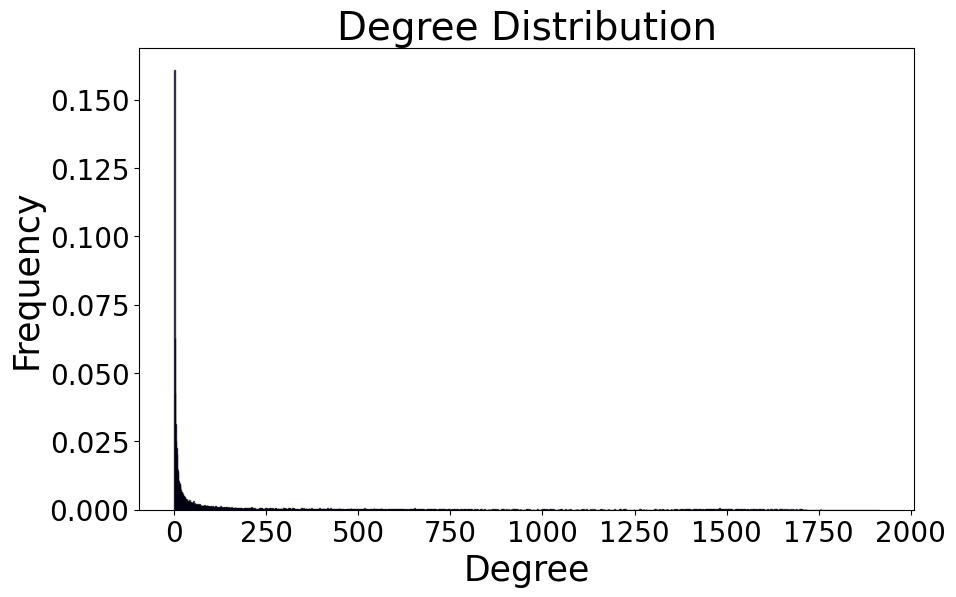

Number of clusters: 8055
Number of modules: 1567
IGRAPH UNW- 26571 2589516 -- 
+ attr: name (v), weight (e)
Number of connected components: 4356


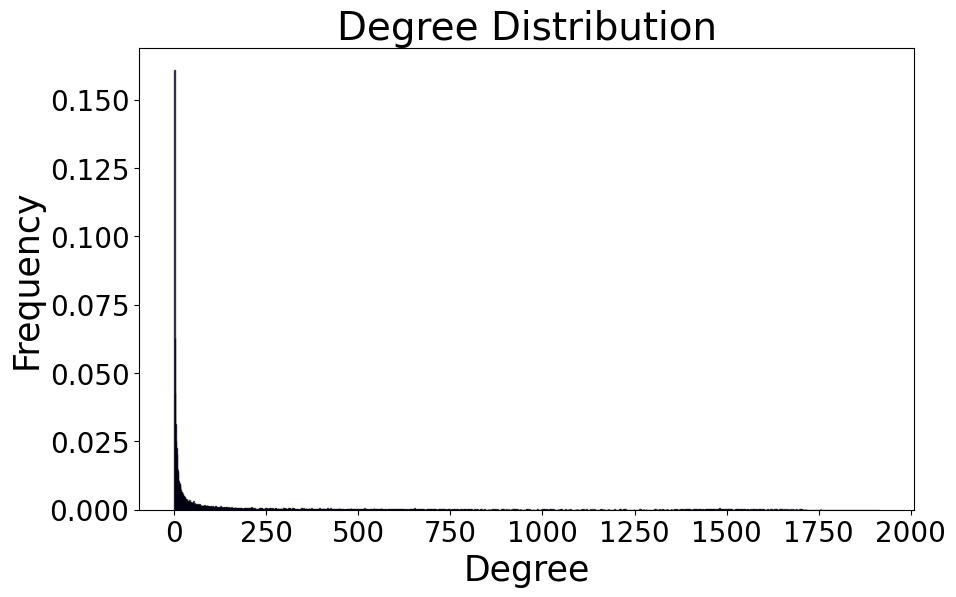

Number of clusters: 8835
Number of modules: 1493
IGRAPH UNW- 26571 2589516 -- 
+ attr: name (v), weight (e)
Number of connected components: 4356


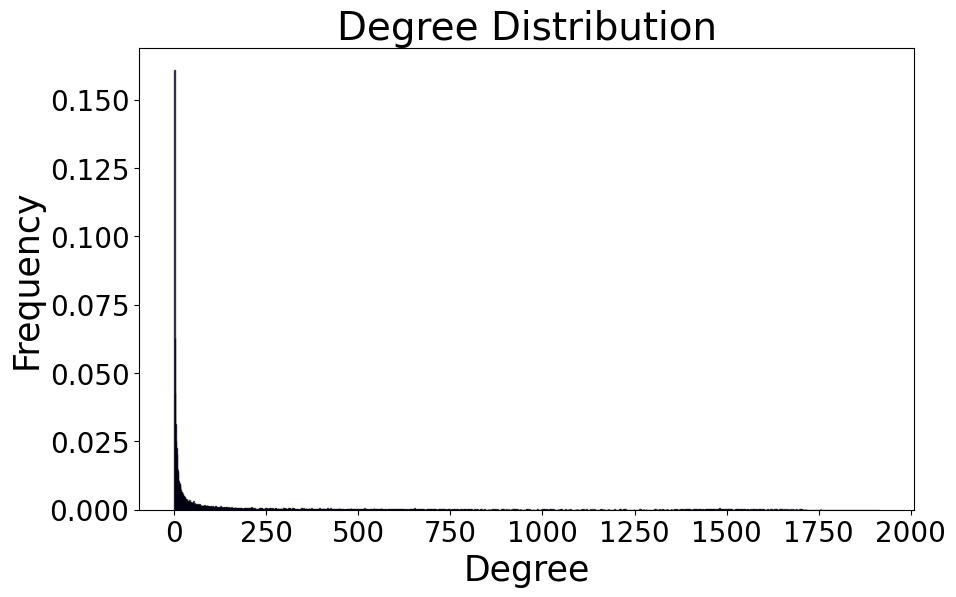

KeyboardInterrupt: 

In [7]:
resolution_values = [0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5]  # for pcc_threshold = 0.3: 20~330 modules

for resolution_parameter in resolution_values:
    module_ctrl = Leiden_pcc_to_module(pcc_matrix=pcc_ctrl, fig_path1=f"../figures/degree_distribution_ctrl_{resolution_parameter}.png", fig_path2=f"../figures/distance_distribution_ctrl_{resolution_parameter}.png", fig_path3=f"../figures/weight_distribution_ctrl_{resolution_parameter}.png", pcc_threshold=0.7, resolution_parameter=resolution_parameter, seed=123456)
    module_to_json(module_dict=module_ctrl, file_path=f"module_ctrl_{resolution_parameter}.json")

In [ ]:
del module_ctrl
del pcc_ctrl

In [ ]:
%pwd
%cd /home/jovyan/work/COVID/results/
%pwd
pcc_mild = pd.read_csv("pcc_mild.csv", index_col=0)
pcc_mild.name = "pcc_mild"

In [ ]:
%pwd
%cd /home/jovyan/work/COVID/parameter_tuning/pcc_leiden/Cell/
%pwd
for resolution_parameter in resolution_values:
    module_mild = Leiden_pcc_to_module(pcc_matrix=pcc_mild, fig_path1=f"../figures/degree_distribution_mild_{resolution_parameter}.png", fig_path2=f"../figures/distance_distribution_mild_{resolution_parameter}.png", fig_path3=f"../figures/weight_distribution_mild_{resolution_parameter}.png", pcc_threshold=0.7, resolution_parameter=resolution_parameter, seed=123456)
    module_to_json(module_dict=module_mild, file_path=f"module_mild_{resolution_parameter}.json")

In [ ]:
del module_mild
del pcc_mild

In [ ]:
%pwd
%cd /home/jovyan/work/COVID/results/
%pwd
pcc_severe = pd.read_csv("pcc_severe.csv", index_col=0)
pcc_severe.name = "pcc_severe"

In [ ]:
%pwd
%cd /home/jovyan/work/COVID/parameter_tuning/pcc_leiden/Cell/
%pwd
for resolution_parameter in resolution_values:
    module_severe = Leiden_pcc_to_module(pcc_matrix=pcc_severe, fig_path1=f"../figures/degree_distribution_severe_{resolution_parameter}.png", fig_path2=f"../figures/distance_distribution_severe_{resolution_parameter}.png", fig_path3=f"../figures/weight_distribution_severe_{resolution_parameter}.png", pcc_threshold=0.7, resolution_parameter=resolution_parameter, seed=123456)
    module_to_json(module_dict=module_severe, file_path=f"module_severe_{resolution_parameter}.json")

In [ ]:
del module_severe
del pcc_severe